## Introduction

This notebook shows training of the ResNet model - First CNN appraoch.

## Setup

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from skin_lesion_project.processing.image_processing import training_data_transforms, test_val_transforms

from skin_lesion_project.datasets.dataloader import create_dataloaders
from skin_lesion_project.models.resnet import get_resnet50
from skin_lesion_project.training.train import train

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

NUM_CLASSES = 8
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

Device : cuda
GPU : NVIDIA GeForce MX150


In [3]:
DEVICE

device(type='cuda')

## Data Loaders

In [4]:
train_loader, val_loader, class_weights = create_dataloaders(
    train_image_dir="/mnt/d/skin-lesion-data/final-data/train",
    train_label_file="/mnt/d/skin-lesion-data/final-data/labels/mappings.pkl",
    val_image_dir="/mnt/d/skin-lesion-data/final-data/test",
    val_label_file="/mnt/d/skin-lesion-data/final-data/test_labels/mappings_test.pkl",
    train_transform=training_data_transforms(),
    val_transform=test_val_transforms(), batch_size=BATCH_SIZE, subset_fraction=1)

Training Images   : 30931
Validation Images : 8238
Batch Size        : 8
Workers           : 4


## Images

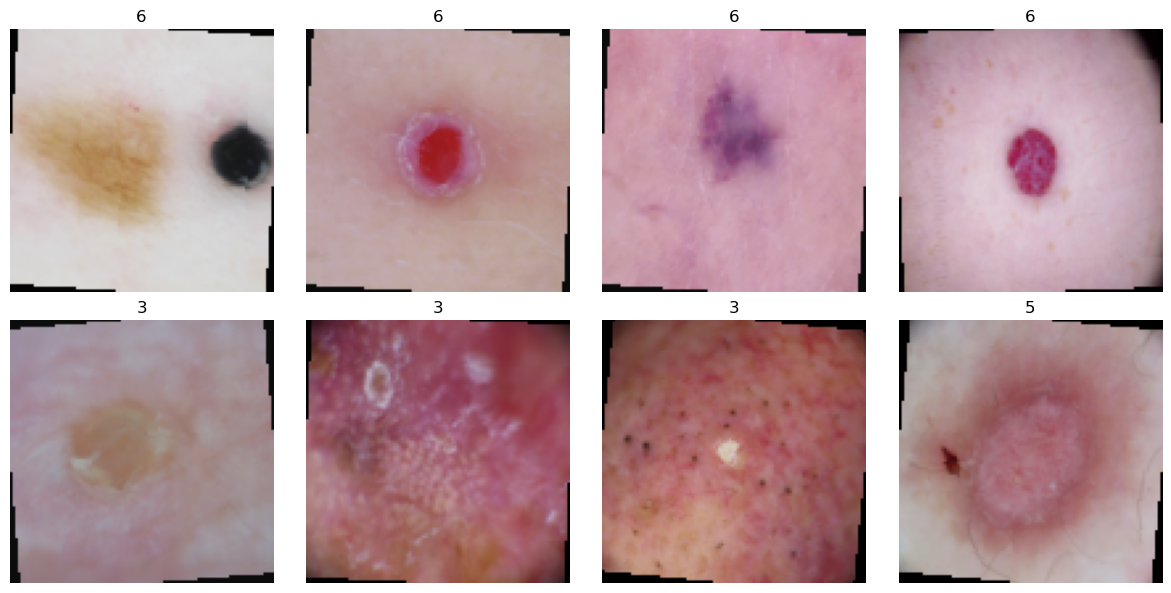

In [5]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2,4, figsize=(12,6))
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

for i, ax in enumerate(axes.flat):
    image = images[i].cpu()
    image = image * std + mean
    image = image.clamp(0,1)
    ax.imshow(image.permute(1,2,0))
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.tight_layout()
plt.show()

## ResNet Model

In [6]:
model = get_resnet50(num_classes=NUM_CLASSES, pretrained=True)
model.to(DEVICE)
model.freeze_backbone()

In [7]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.1)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = train(model=model, train_loader=train_loader, val_loader=val_loader,
                criterion=criterion, optimizer=optimizer,
                scheduler=scheduler, device=DEVICE,
                epochs=EPOCHS, checkpoint_path="checkpoints/resnet50_classifier.pt")

Epoch 1/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3867/3867 [12:31<00:00,  5.14it/s, loss=1.8651]


Best model saved.
Epoch 1/30
Train Loss : 1.3044619307840666
Val Loss   : 3.53804125007885
Train Acc  : 0.28935372280236654
Val Acc    : 0.05571740713765477
Precision  : 0.29209749274119573
Recall     : 0.2544186496187624
Macro F1   : 0.05783140796206425


Epoch 2/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3867/3867 [13:00<00:00,  4.95it/s, loss=3.9763]


Best model saved.
Epoch 2/30
Train Loss : 1.151915716495189
Val Loss   : 3.6486174091316883
Train Acc  : 0.3527205715948401
Val Acc    : 0.0668851663025006
Precision  : 0.30103343708028374
Recall     : 0.2668882353475925
Macro F1   : 0.07079084653426994


Epoch 3/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3867/3867 [12:42<00:00,  5.07it/s, loss=1.9915]


Best model saved.
Epoch 3/30
Train Loss : 1.111641683917955
Val Loss   : 3.744308413160342
Train Acc  : 0.3742200381494294
Val Acc    : 0.07999514445253703
Precision  : 0.33221708269019806
Recall     : 0.27805418399313814
Macro F1   : 0.08267162125945302


Epoch 4/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3867/3867 [12:56<00:00,  4.98it/s, loss=1.2911]


Epoch 4/30
Train Loss : 1.097171810456373
Val Loss   : 3.6659595671137666
Train Acc  : 0.38155895380039445
Val Acc    : 0.07465404224326293
Precision  : 0.30946732641501157
Recall     : 0.272026768176281
Macro F1   : 0.08175181423893822


Epoch 5/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3867/3867 [14:09<00:00,  4.55it/s, loss=1.4489]


KeyboardInterrupt: 

In [ ]:


model.unfreeze_backbone()

optimizer = AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(

    optimizer,

    T_max=20,
)

history_finetune = train(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    device=DEVICE,

    epochs=20,

    checkpoint_path="checkpoints/resnet50_finetuned.pt",
)

# ============================================================
# Plot Loss
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history_finetune["train_loss"], label="Train")

plt.plot(history_finetune["val_loss"], label="Validation")

plt.legend()

plt.grid(True)

plt.title("Loss")

plt.show()

# ============================================================
# Plot Accuracy
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history_finetune["train_accuracy"], label="Train")

plt.plot(history_finetune["val_accuracy"], label="Validation")

plt.legend()

plt.grid(True)

plt.title("Accuracy")

plt.show()

# ============================================================
# Plot Macro F1
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history_finetune["macro_f1"])

plt.grid(True)

plt.title("Validation Macro F1")

plt.show()

# ============================================================
# Save Training History
# ============================================================

history_df = pd.DataFrame(history_finetune)

history_df.to_csv(

    "results/resnet50_history.csv",

    index=False,
)

history_df.head()

# ============================================================
# Best Results
# ============================================================

print(
    f"Best Validation Accuracy : "
    f"{max(history_finetune['val_accuracy']):.4f}"
)

print(b
    f"Best Validation Macro F1 : "
    f"{max(history_finetune['macro_f1']):.4f}"
)

In [8]:
import pickle

with open("/mnt/d/skin-lesion-data/final-data/test_labels/mappings_test.pkl", "rb") as f:
    labels = pickle.load(f)

print(next(iter(labels.items())))

('ISIC_0034321', 'NV')
